# Exploratory analysis — Forecasting & Decision Intelligence Engine

This notebook walks through the analysis layer of the engine: data validation, EDA, seasonality, and anomaly detection. It uses the same `app` modules the API and dashboard rely on, so the analysis here is exactly what the product runs.

## 1. Load the sample dataset

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "app").is_dir():
        sys.path.insert(0, str(p))
        break

import pandas as pd
import numpy as np

from app.data.sample_data import generate_business_demand

df = generate_business_demand(n_days=1095, seed=42)
df.head()

,date,target
0,2021-01-01,988.08
1,2021-01-02,747.42
2,2021-01-03,852.44
3,2021-01-04,1018.97
4,2021-01-05,888.83


## 2. Validation report

In [2]:
from app.data.validator import DataValidator

report = DataValidator().validate(df)
report.to_dict()

{'is_valid': True,
 'quality_score': 100.0,
 'missing_values': 0,
 'duplicate_records': 0,
 'date_coverage_days': 1095,
 'detected_frequency': 'D',
 'n_observations': 1095,
 'outlier_count': 0,
 'target_constant': False,
 'issues': [],
 'transformations_applied': ['Parsed date column and sorted chronologically']}

## 3. Automated EDA

In [3]:
from app.data.preprocessing import Preprocessor
from app.analysis.eda import EDAAnalyzer

prepped = Preprocessor().preprocess(df)
eda = EDAAnalyzer().analyze(prepped.series, frequency=prepped.frequency)
eda.to_dict()

{'n_observations': 1095,
 'date_range': {'start': '2021-01-01', 'end': '2023-12-31'},
 'frequency': 'D',
 'trend': {'direction': 'increasing',
  'slope_per_period': 0.302488,
  'slope_pct_per_period': np.float64(0.0303),
  'p_value': 0.0},
 'seasonality': {'primary': 'weekly',
  'strength': np.float64(0.8954399812340612),
  'periods': {'weekly': {'period': 7, 'strength': np.float64(0.895)},
   'yearly': {'period': 365, 'strength': np.float64(0.803)}}},
 'volatility': {'overall_std': 183.5054,
  'recent_std': 109.4229,
  'early_std': 105.5909,
  'ratio_recent_to_early': np.float64(1.0363),
  'trend': 'stable'},
 'anomalies': {'count': 0, 'method': 'IQR (3x) on target', 'dates': []},
 'summary_stats': {'min': 419.22,
  'max': 1515.38,
  'mean': 997.8459999999999,
  'median': 998.4,
  'std': 183.5054374685173,
  'recent_value': 1120.07,
  'first_value': 988.08,
  'latest_change_pct': -3.3756},
 'decomposition': {'method': 'additive',
  'period': 7,
  'trend_last': 1253.8739795918364,
  's

## 4. Visual exploration

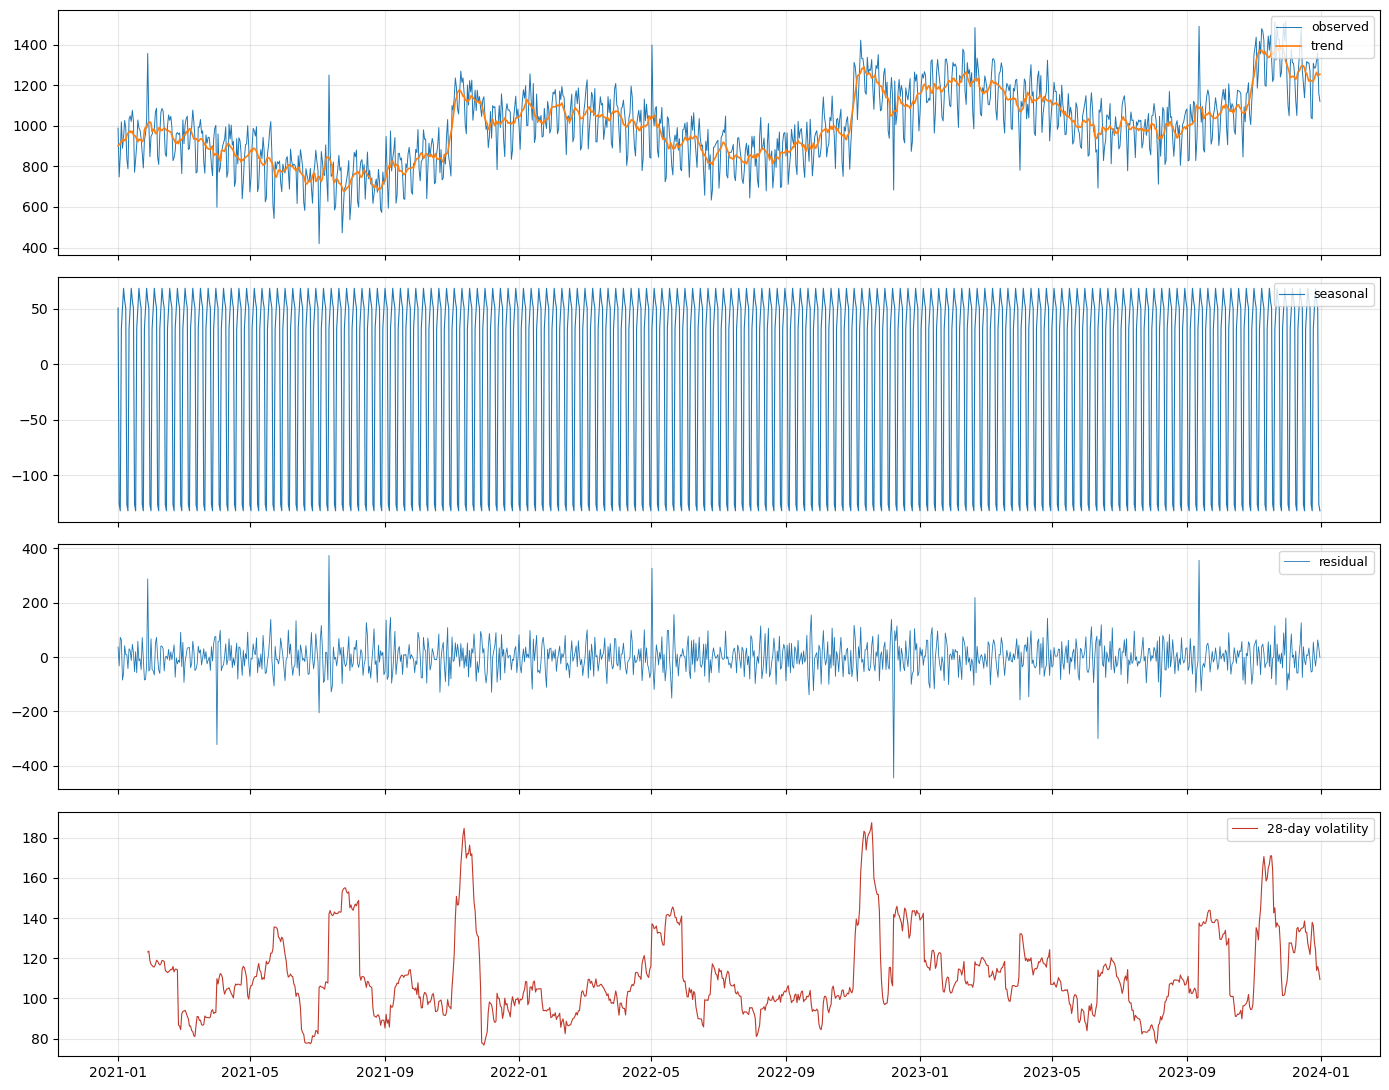

In [4]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

s = prepped.series
decomp = seasonal_decompose(s, model="additive", period=7, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
axes[0].plot(s.index, s, lw=0.7, label="observed")
axes[0].plot(s.index, decomp.trend, lw=1.2, label="trend")
axes[1].plot(s.index, decomp.seasonal, lw=0.8, label="seasonal")
axes[2].plot(s.index, decomp.resid, lw=0.6, label="residual")
s2 = s.rolling(28).std()
axes[3].plot(s2.index, s2, lw=0.8, label="28-day volatility", color="#c0392b")
for ax in axes:
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Full pipeline in one call

In [5]:
from app.forecasting.pipeline import ForecastingPipeline, PipelineConfig

result = ForecastingPipeline(config=PipelineConfig(horizon=30, backtest_folds=3)).run(df, horizon=30)
print("Best model:", result.backtest["best_model"], "| score:", result.backtest["best_score"])
print("Forecast horizon:", result.forecast["horizon"], "| last value:", result.forecast["forecast"][-1])
print("Drivers:", [d["driver"] for d in result.explainability["drivers"]])

Best model: xgboost | score: 12.953
Forecast horizon: 30 | last value: 1073.9810112176604
Drivers: ['recent trend', 'recent volatility']
